In [2]:
import sys
print(sys.executable)

c:\Users\gugao\Downloads\fiap-mlet-challenge-fase-1-main - Copia\fiap-mlet-challenge-fase-1-main\.venv\Scripts\python.exe


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print("imports ok")

imports ok


In [ ]:
# leitura do dataset + inspeção inicial

df_raw = pd.read_csv("../data/dataset/telco_customer_churn.csv")
df = df_raw.copy()

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Limpeza

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [12]:
df_raw = pd.read_csv("../data/dataset/telco_customer_churn.csv")
df = df_raw.copy()

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# Inspeção inicial do dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [18]:
df.isnull().sum().sort_values(ascending=False)

TotalCharges        11
gender               0
Partner              0
SeniorCitizen        0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

In [19]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7043,3,No,3088,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# Converter TotalCharges para numérico, transformar Churn em binário e remover customerID

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [21]:
# Verificar novamente os valores ausentes depois da limpeza básica
df.isnull().sum().sort_values(ascending=False)

Churn               7043
TotalCharges          11
gender                 0
SeniorCitizen          0
Dependents             0
Partner                0
tenure                 0
PhoneService           0
OnlineSecurity         0
OnlineBackup           0
MultipleLines          0
InternetService        0
TechSupport            0
DeviceProtection       0
StreamingTV            0
StreamingMovies        0
PaperlessBilling       0
Contract               0
MonthlyCharges         0
PaymentMethod          0
dtype: int64

In [22]:
# Analisar a distribuição da variável alvo Churn

df["Churn"].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

In [23]:
# Verificar a proporção da variável alvo Churn
df["Churn"].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

In [24]:
# Separar colunas numéricas e categóricas para análise exploratória

num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()

if "Churn" in num_cols:
    num_cols.remove("Churn")

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


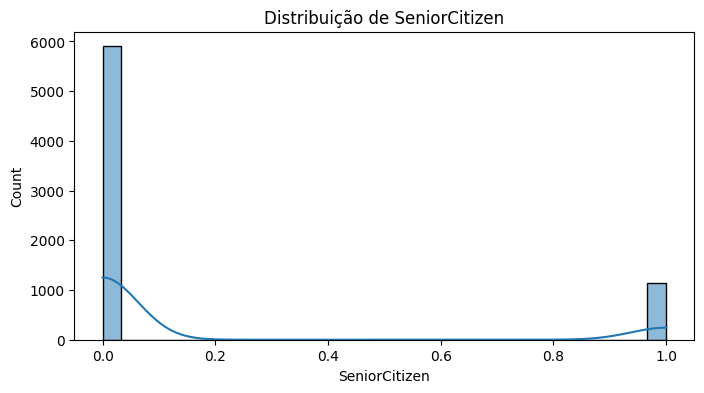

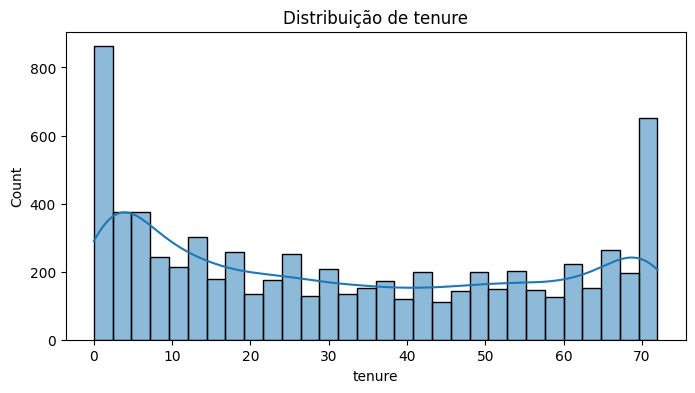

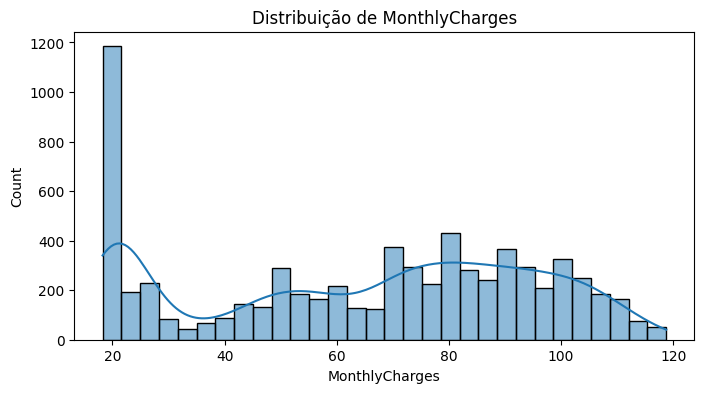

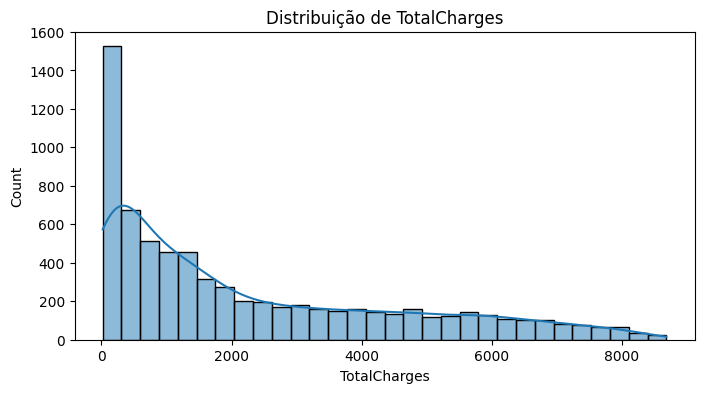

In [25]:
# Plotar a distribuição das variáveis numéricas principais

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribuição de {col}")
    plt.show()

In [27]:
# Comparar as variáveis numéricas principais com Churn usando boxplots, ignorando colunas problemáticas
for col in num_cols:
    temp = df[["Churn", col]].dropna()
    if temp[col].nunique() > 1:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=temp, x="Churn", y=col)
        plt.title(f"{col} por Churn")
        plt.show()

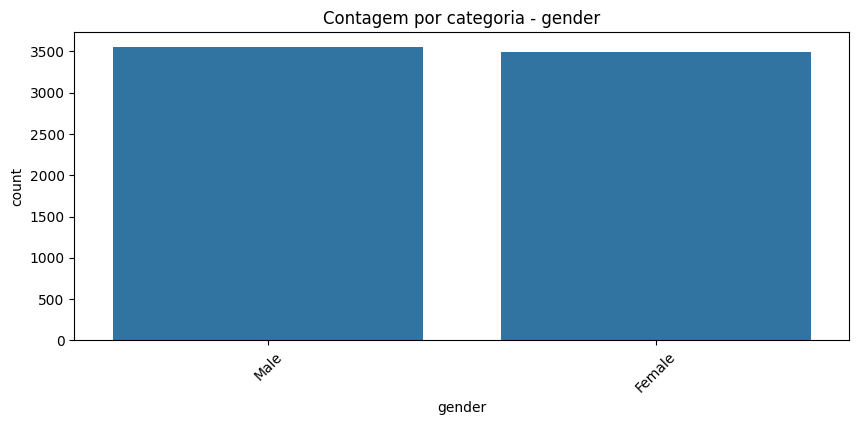

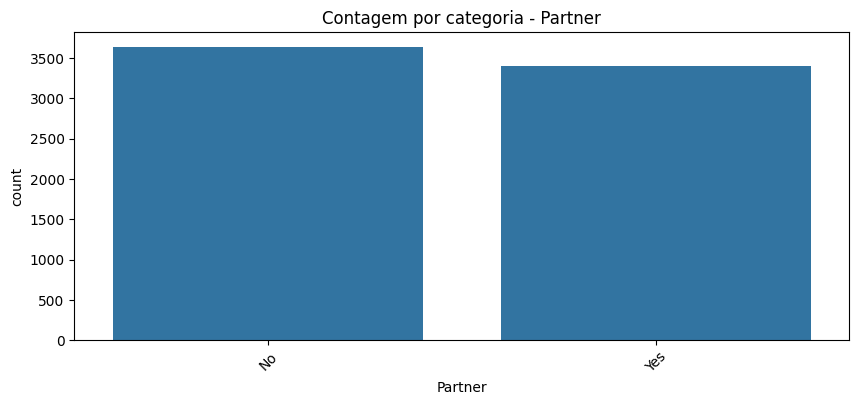

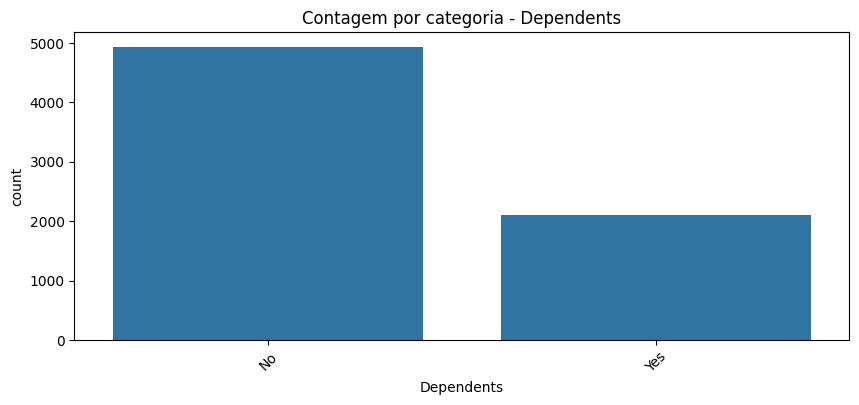

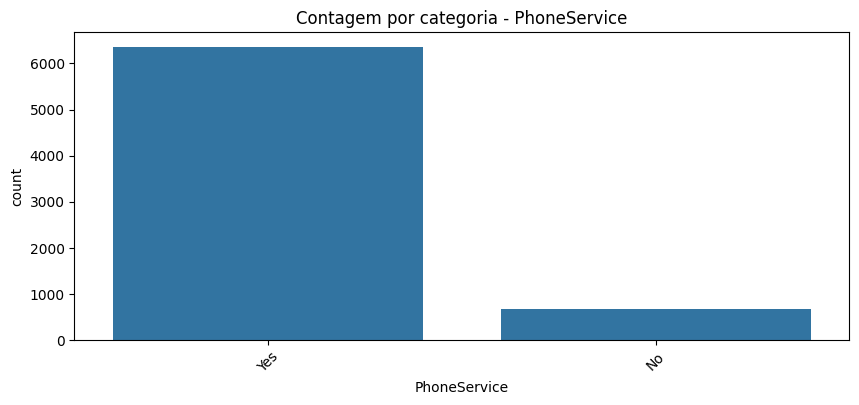

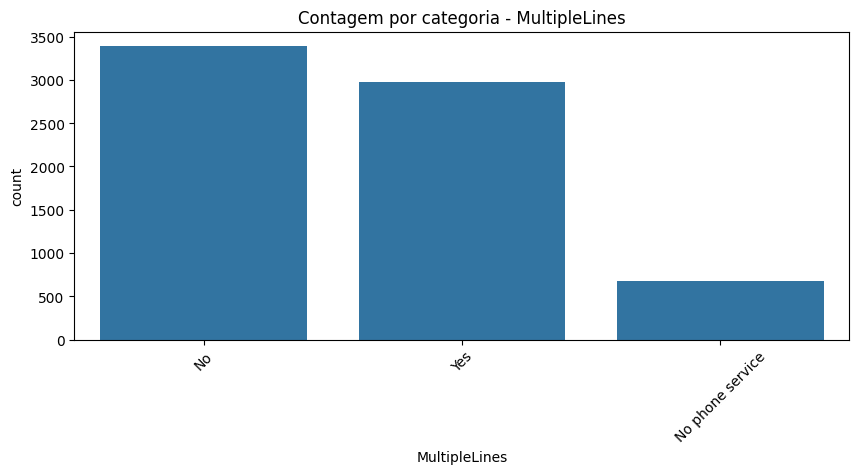

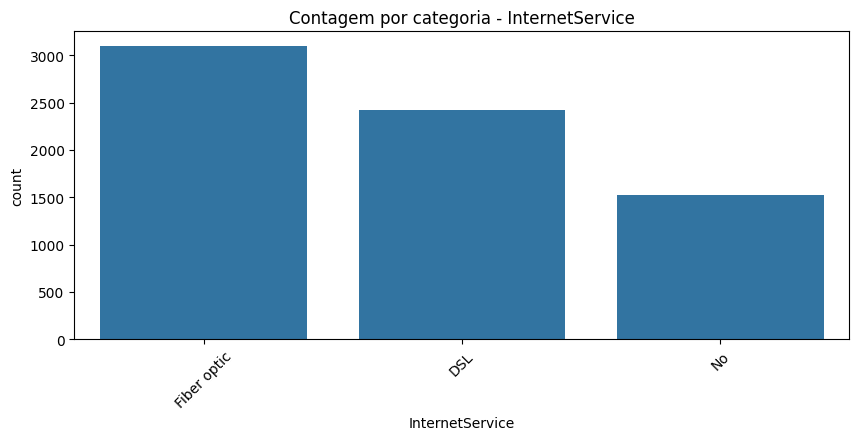

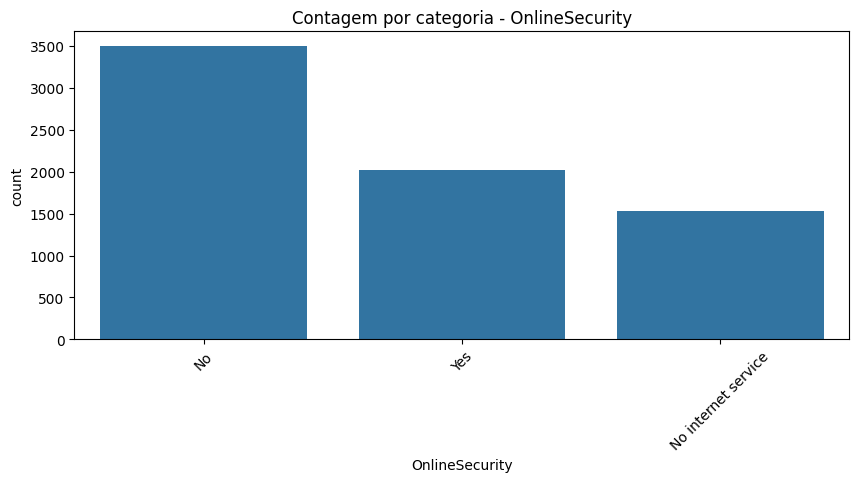

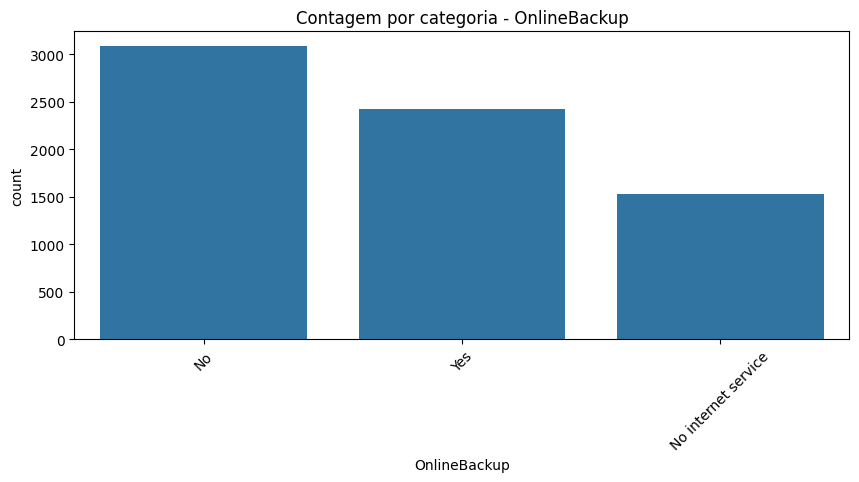

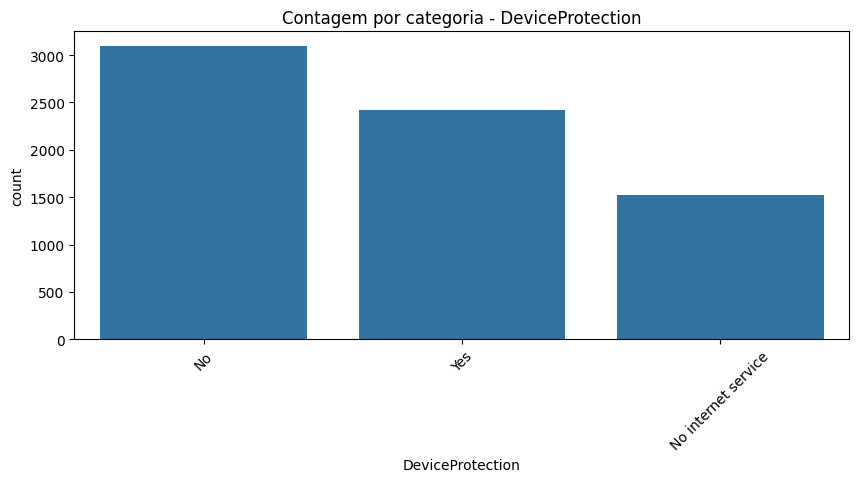

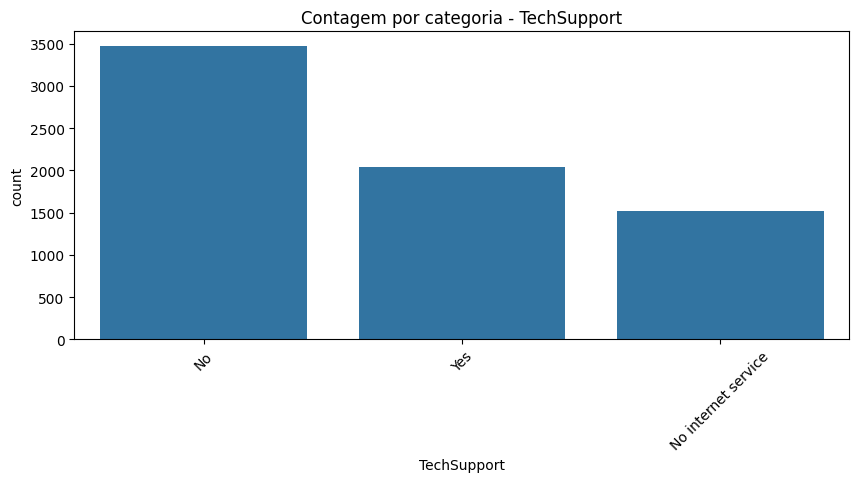

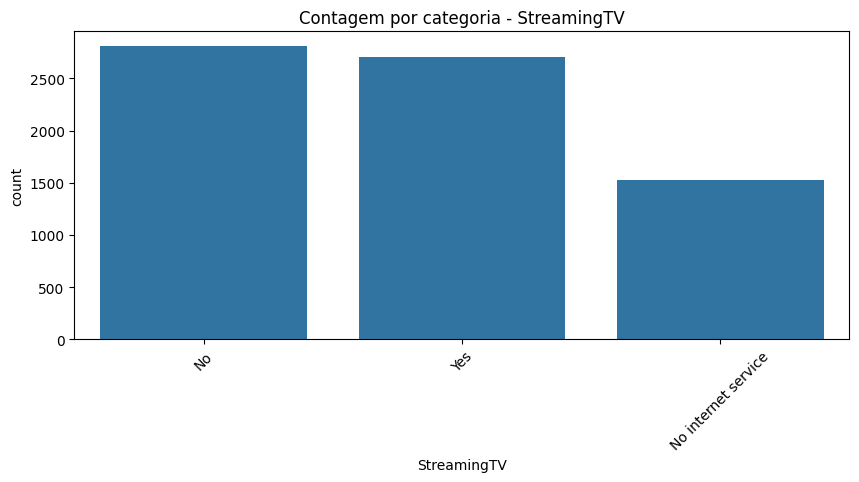

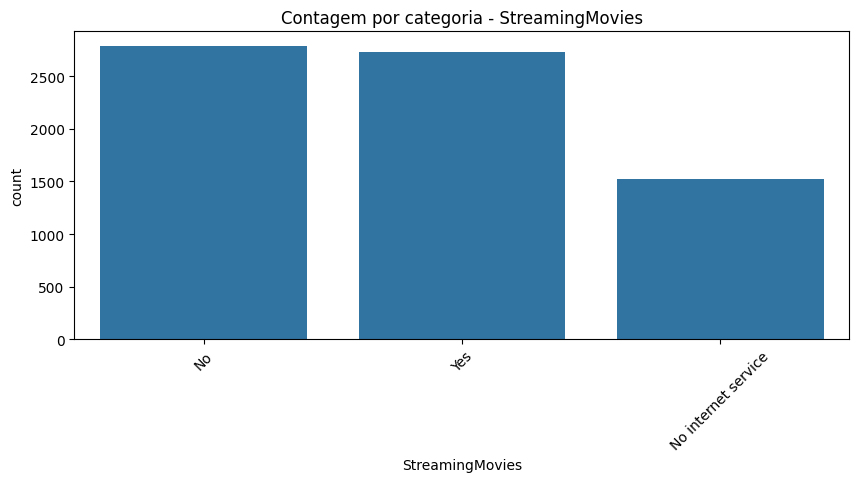

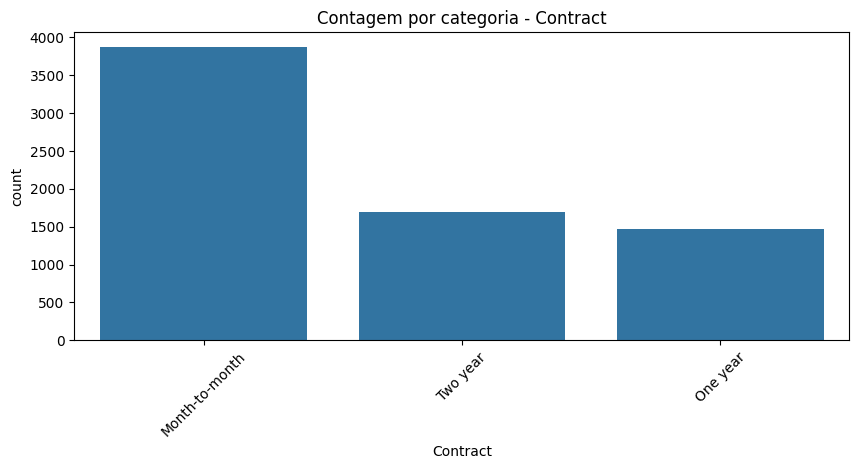

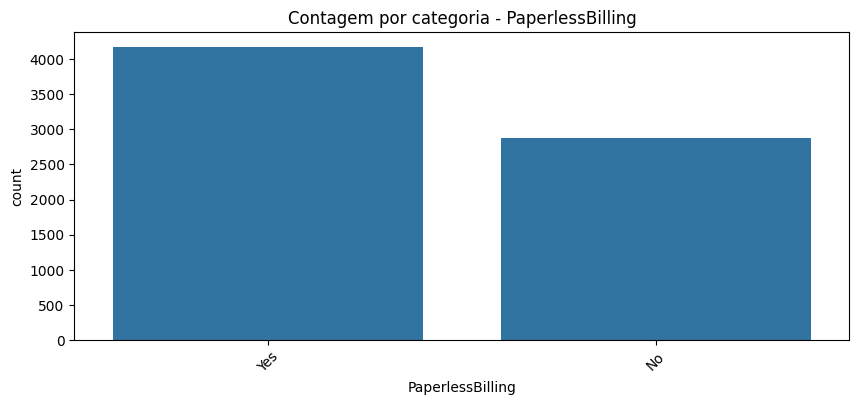

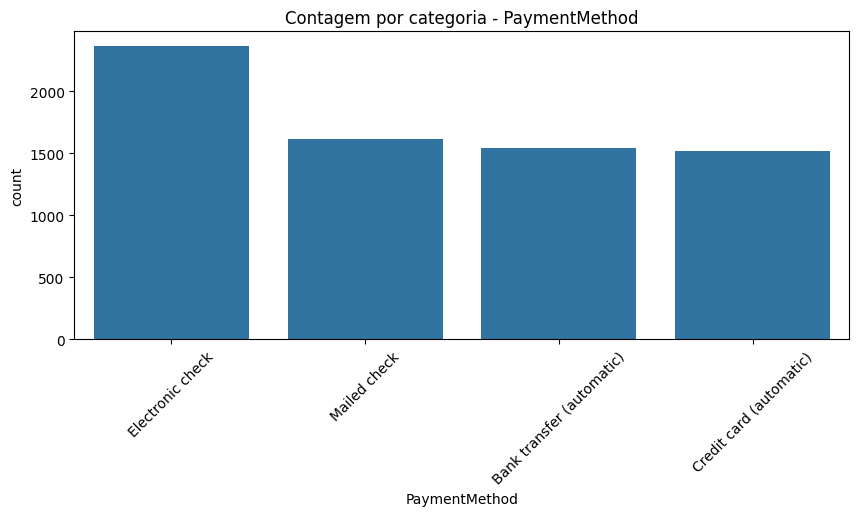

In [28]:
# Plotar a contagem das categorias nas variáveis categóricas
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Contagem por categoria - {col}")
    plt.xticks(rotation=45)
    plt.show()

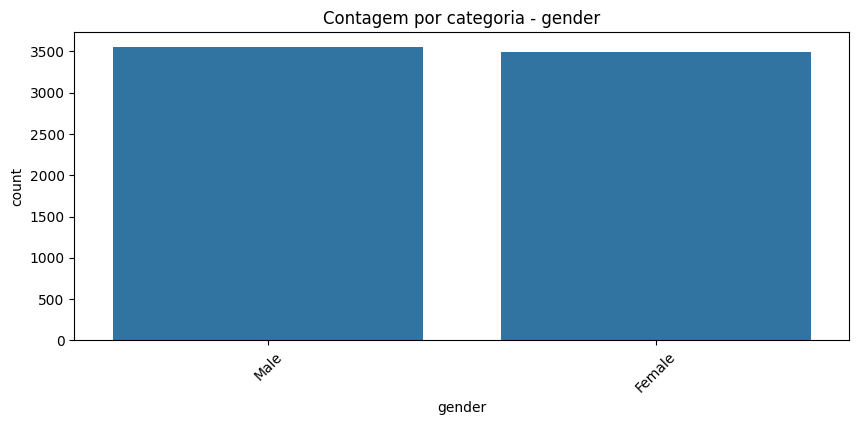

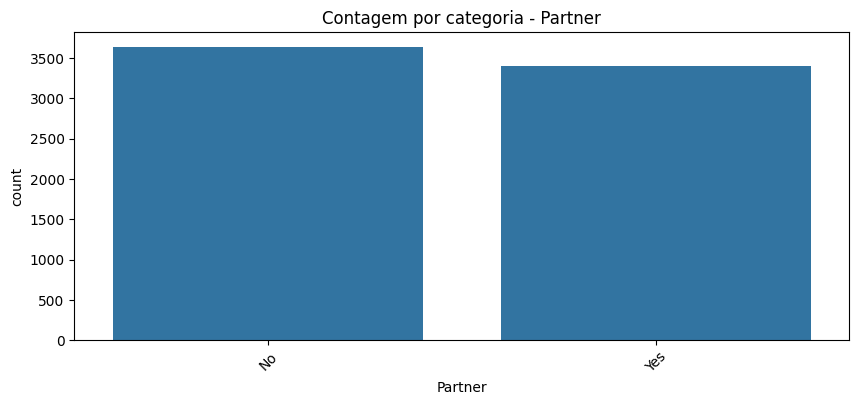

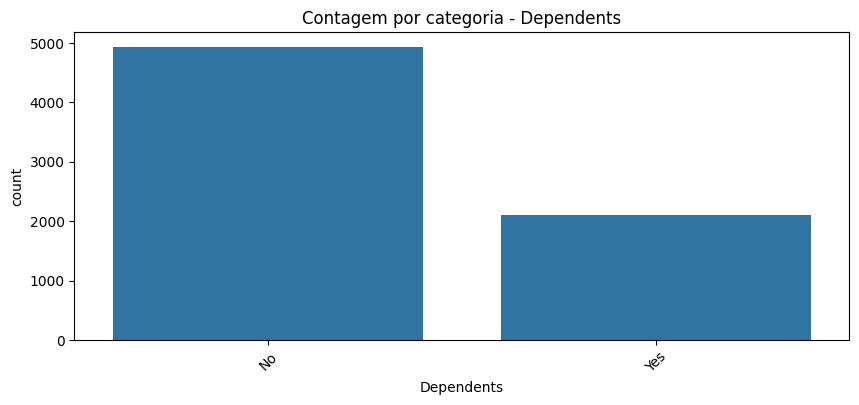

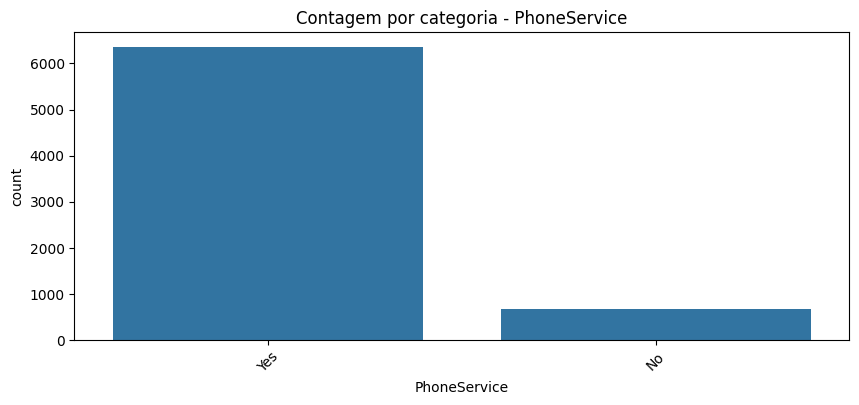

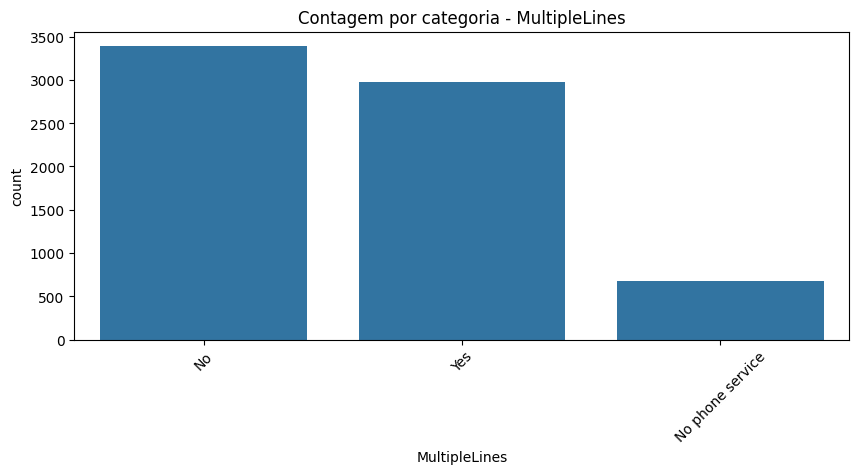

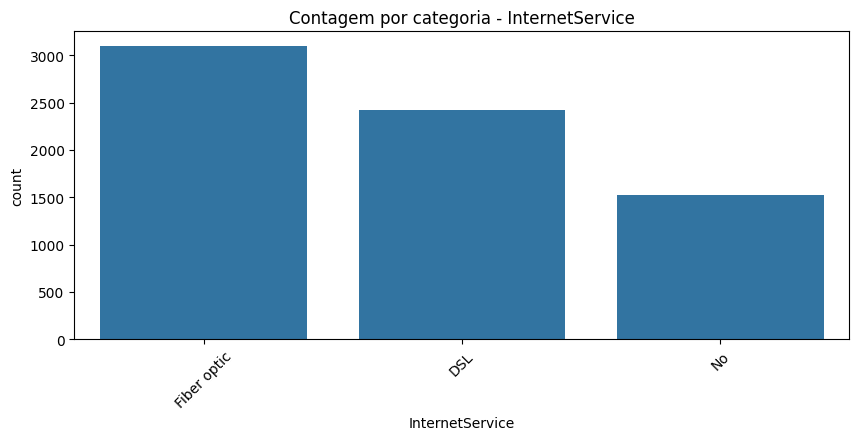

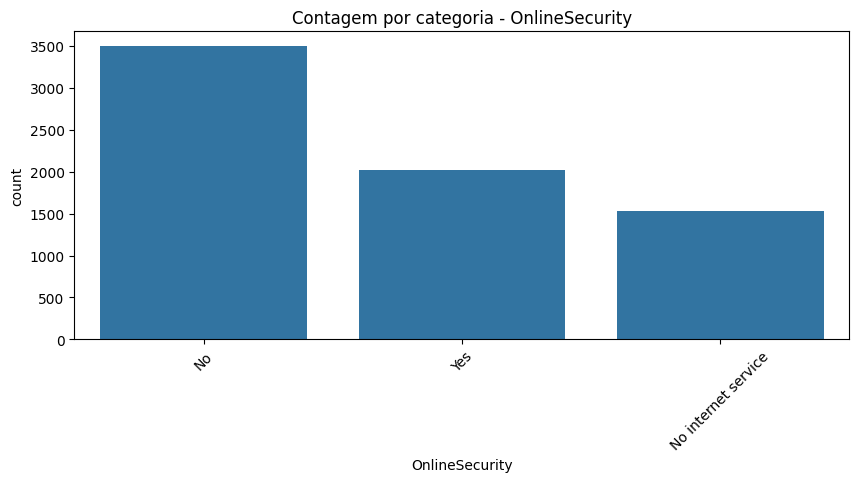

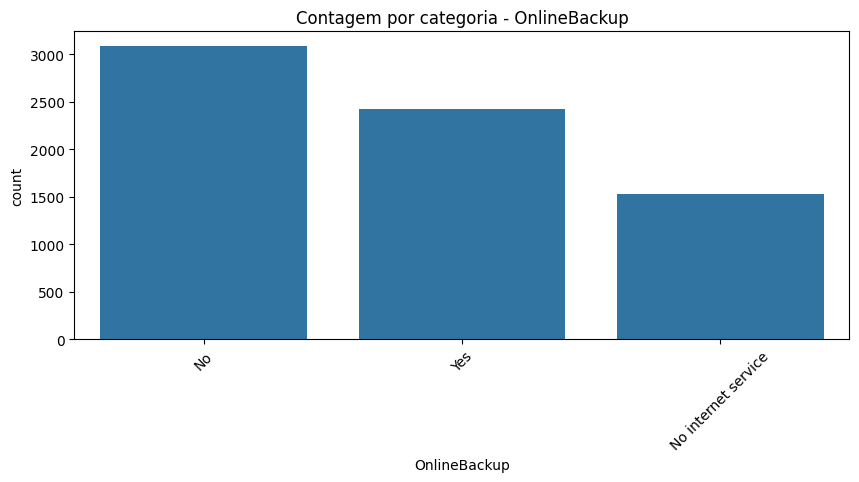

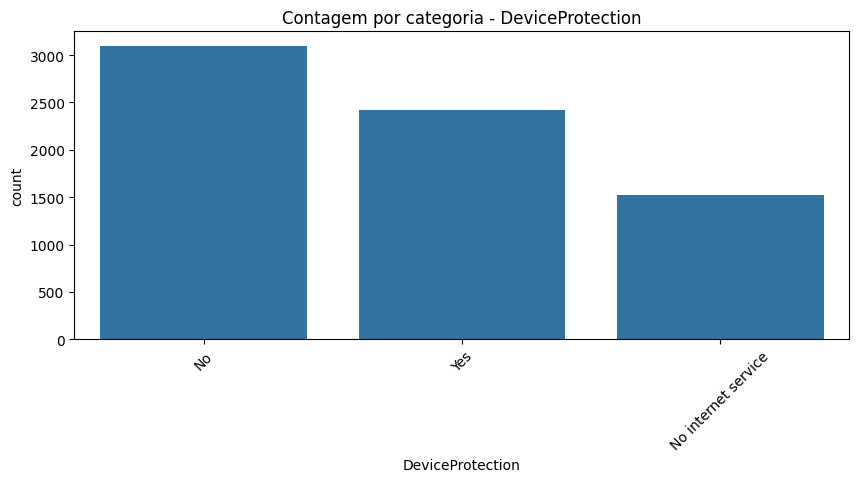

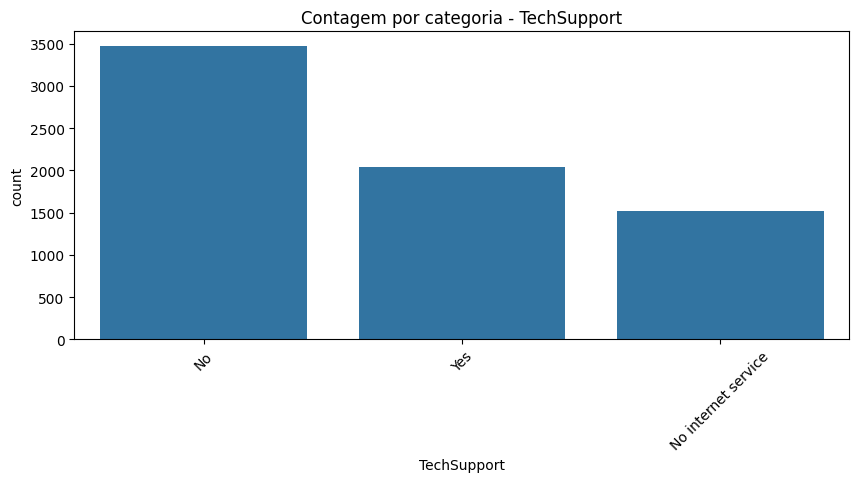

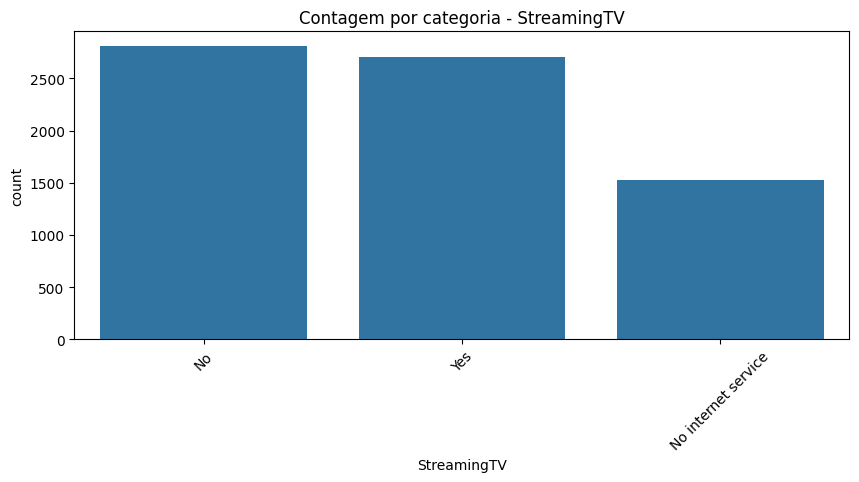

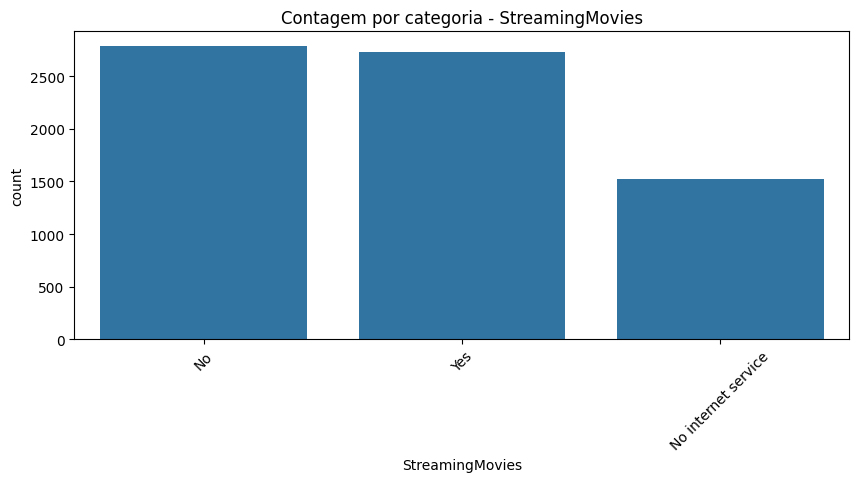

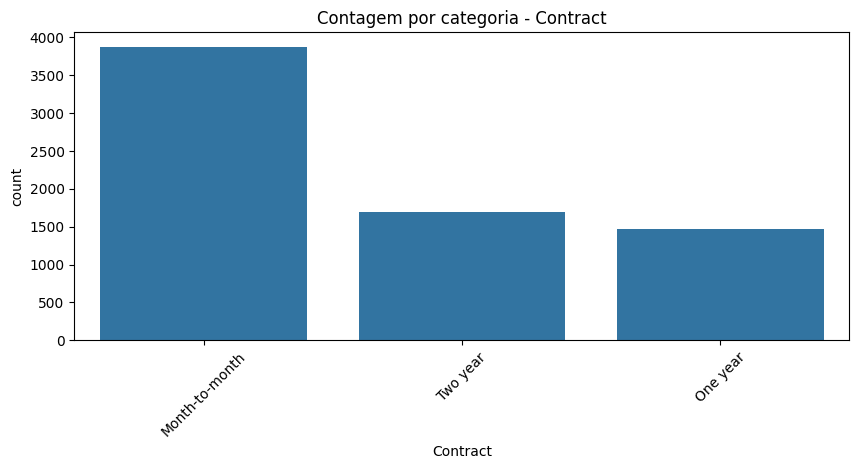

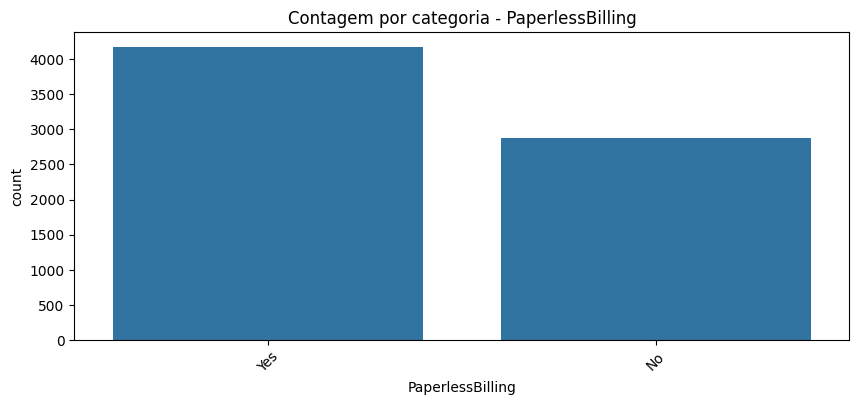

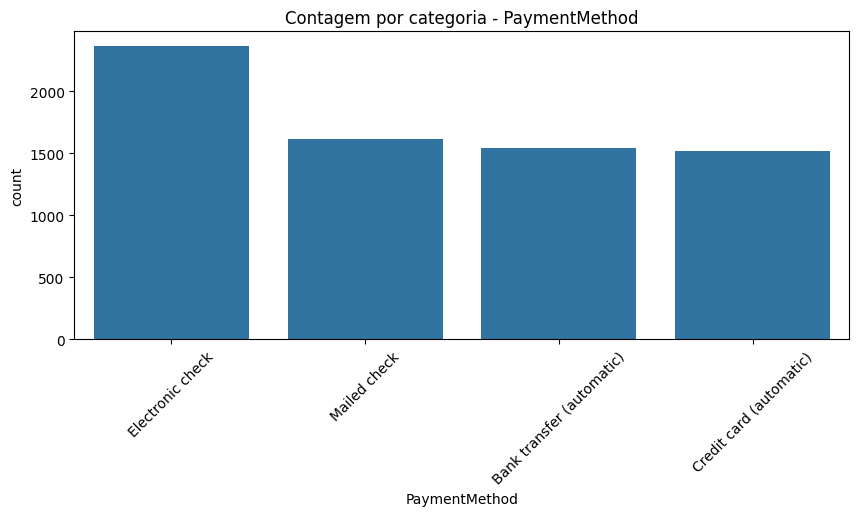

In [29]:
# Plotar a contagem das categorias nas variáveis categóricas
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Contagem por categoria - {col}")
    plt.xticks(rotation=45)
    plt.show()

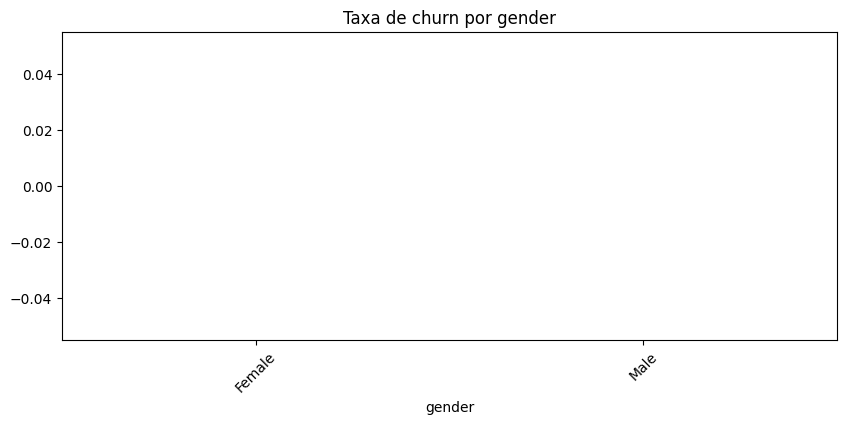

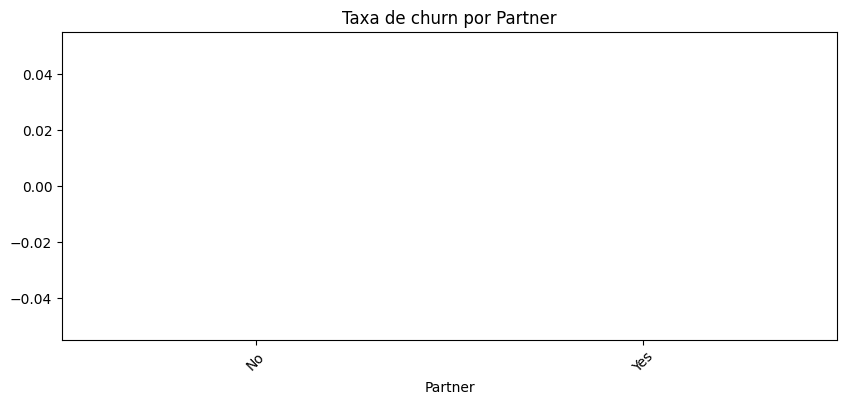

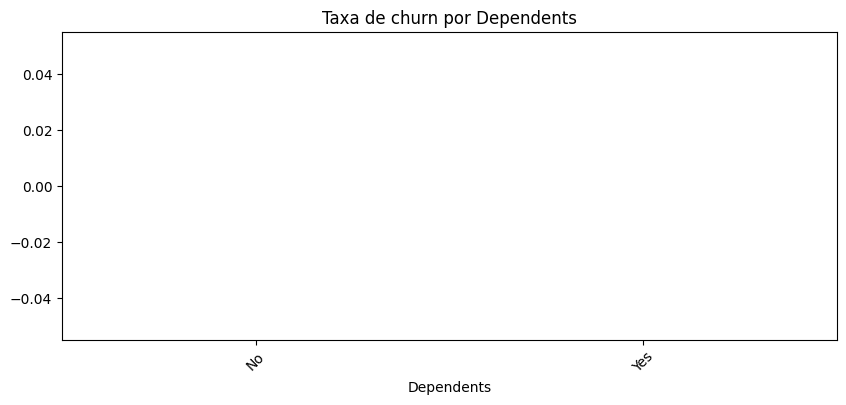

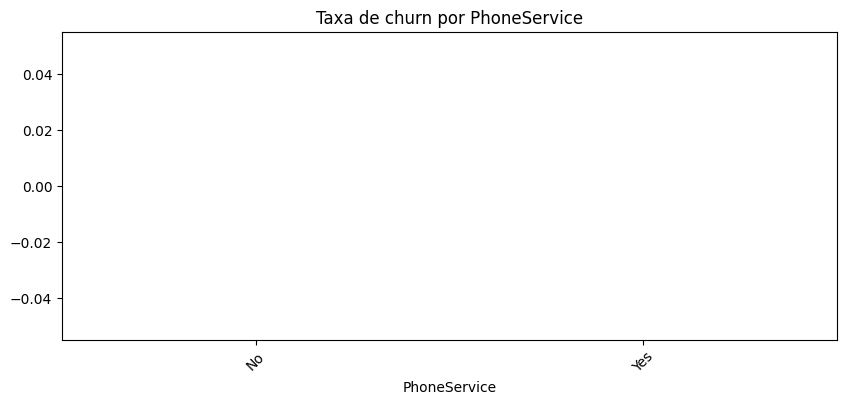

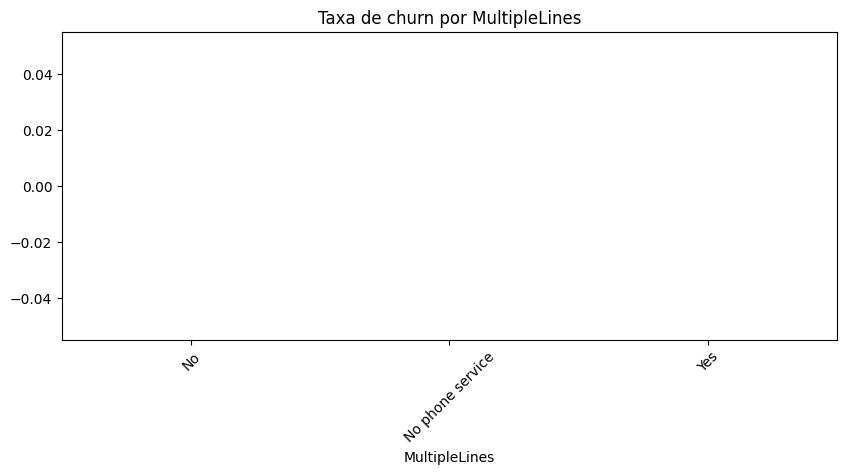

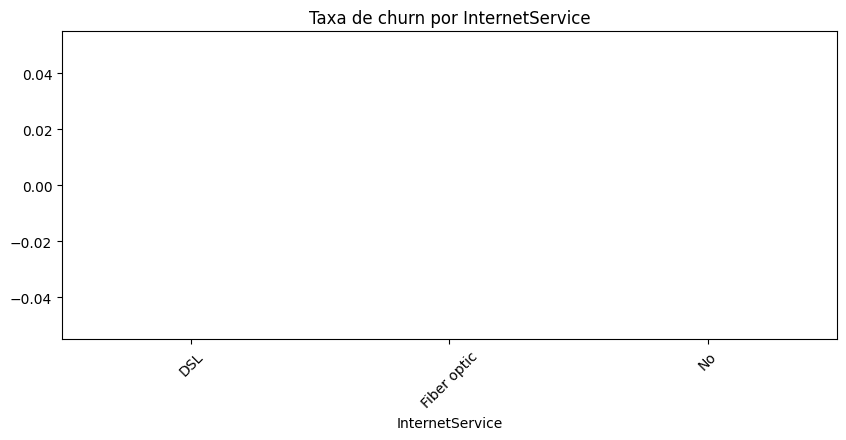

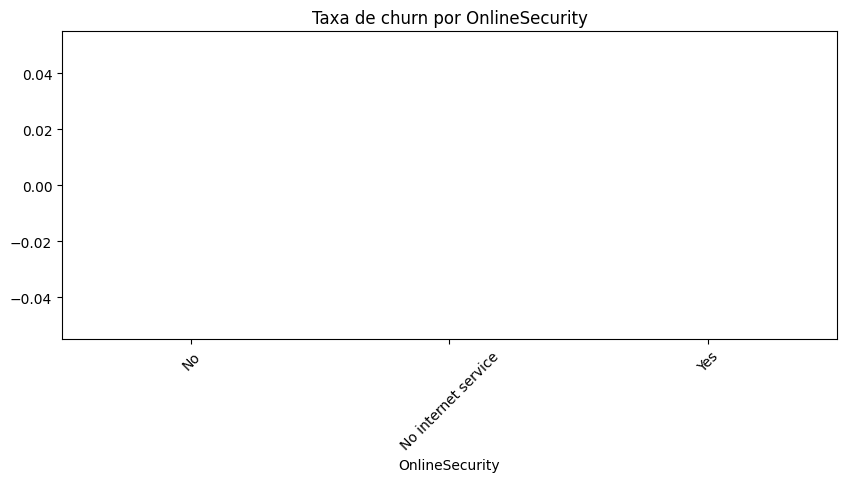

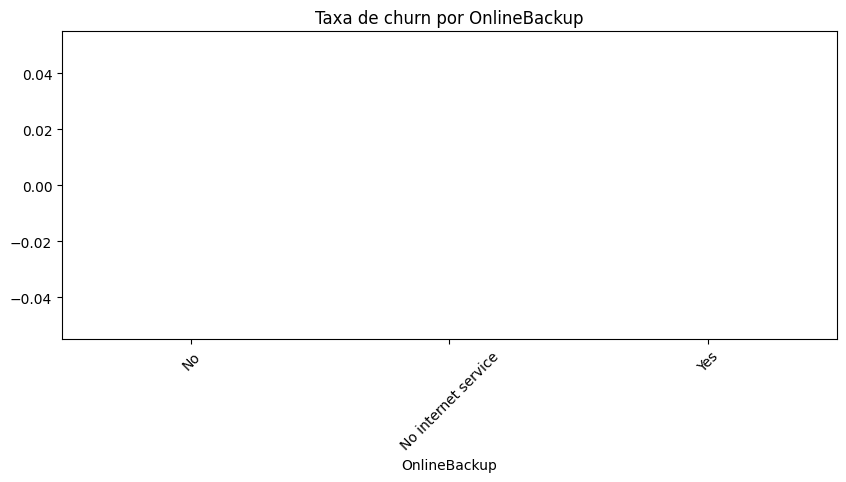

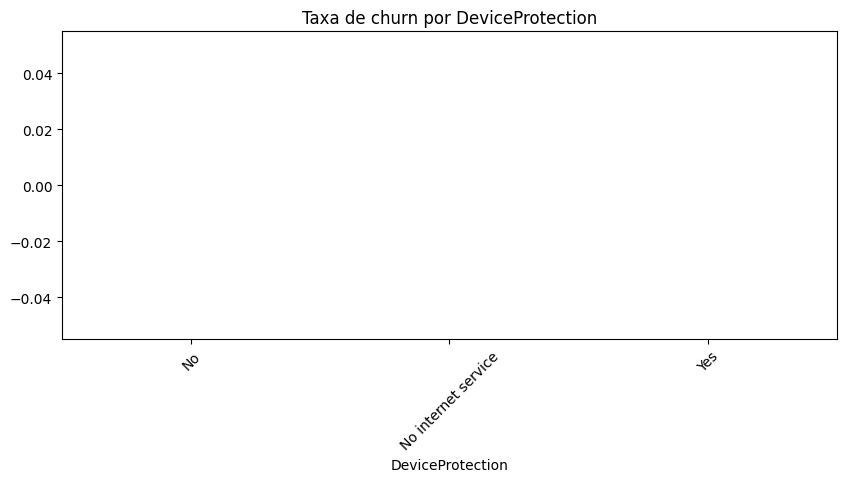

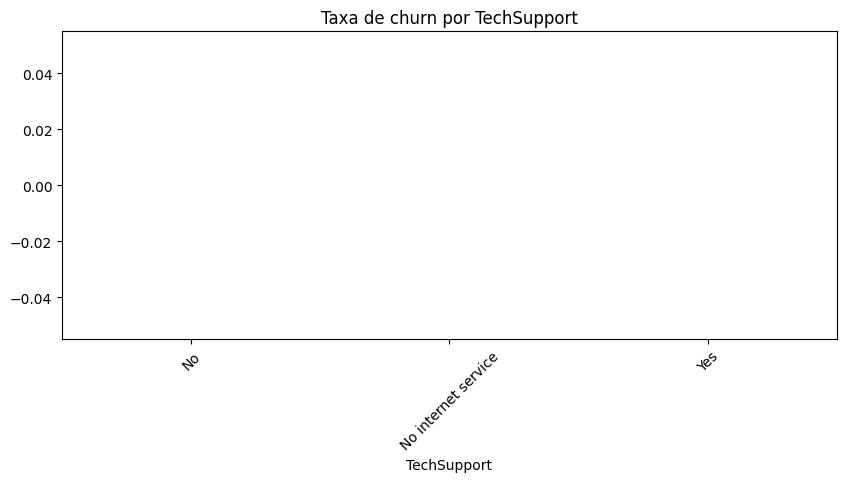

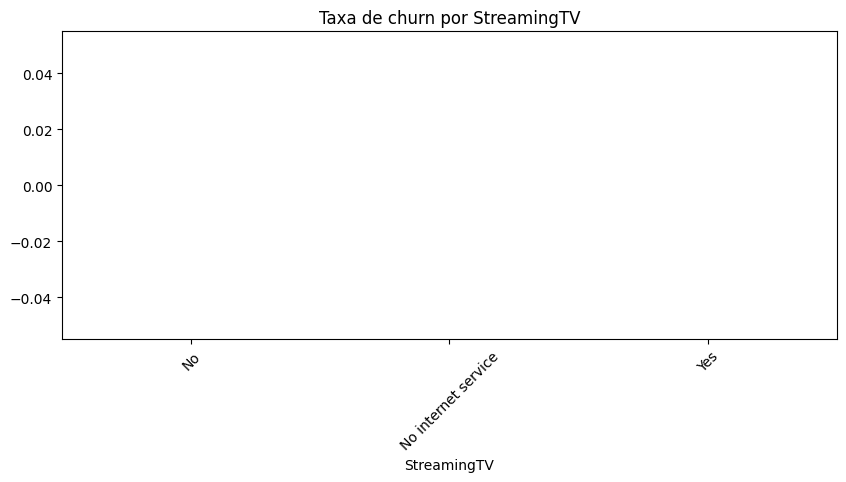

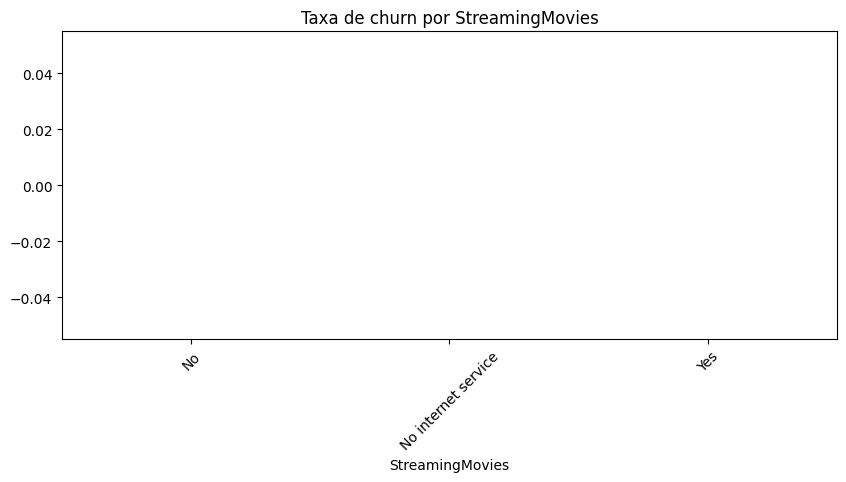

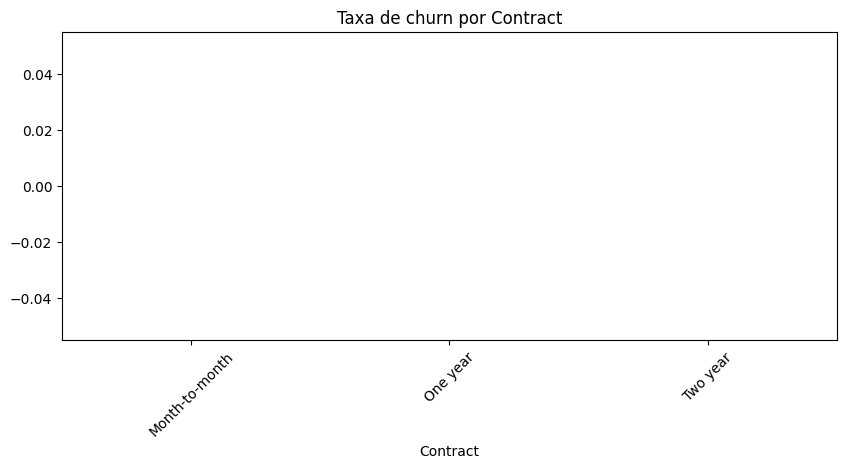

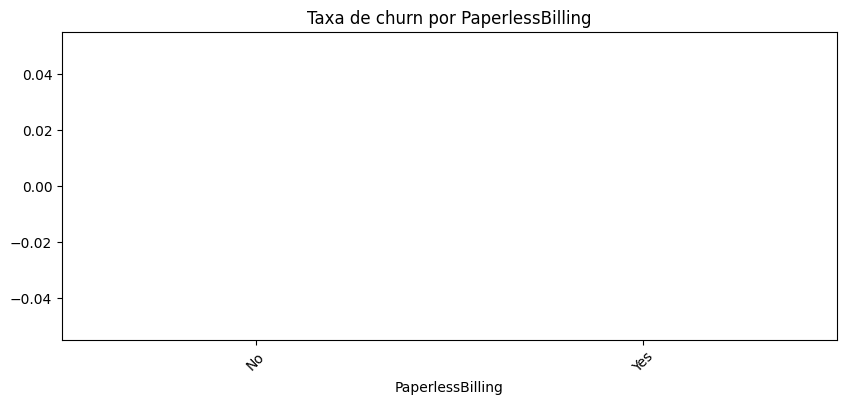

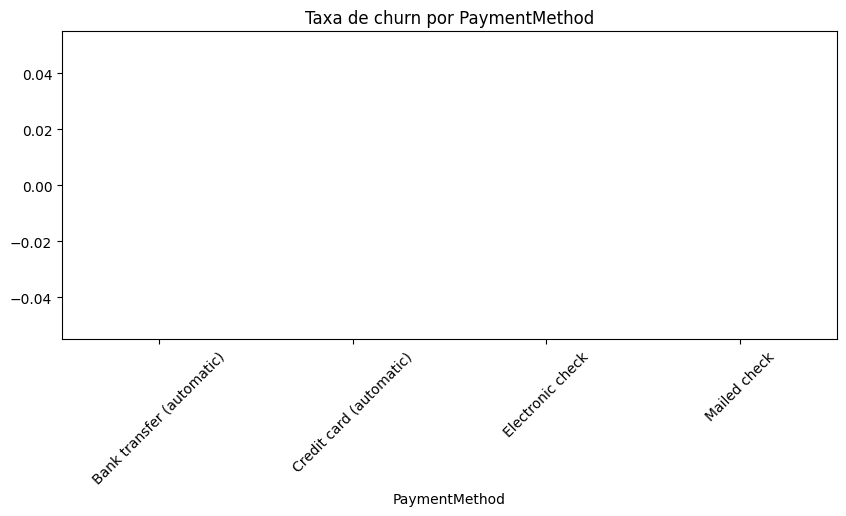

In [30]:
# Comparar a taxa média de churn por categoria
for col in cat_cols:
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f"Taxa de churn por {col}")
    plt.xticks(rotation=45)
    plt.show()

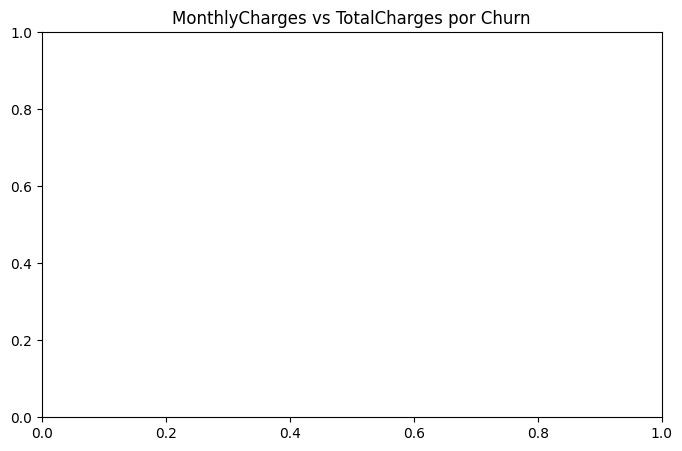

In [31]:
# Verificar a relação entre MonthlyCharges e TotalCharges com Churn
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="MonthlyCharges", y="TotalCharges", hue="Churn", alpha=0.7)
plt.title("MonthlyCharges vs TotalCharges por Churn")
plt.show()

In [32]:
# Resumo das principais observações do EDA
print("Principais insights:")
print("- Churn parece mais alto em contratos month-to-month.")
print("- Tenure baixo tende a estar associado a churn maior.")
print("- MonthlyCharges e PaymentMethod parecem relevantes.")
print("- TotalCharges deve ser tratado com cuidado por conter valores ausentes.")

Principais insights:
- Churn parece mais alto em contratos month-to-month.
- Tenure baixo tende a estar associado a churn maior.
- MonthlyCharges e PaymentMethod parecem relevantes.
- TotalCharges deve ser tratado com cuidado por conter valores ausentes.


In [34]:
# Criar algumas features derivadas para testar hipóteses levantadas no EDA
import numpy as np

df_fe = df.copy()

df_fe["tenure_bucket"] = pd.cut(
    df_fe["tenure"],
    bins=[-1, 12, 24, 48, 72, 120],
    labels=["0-12", "13-24", "25-48", "49-72", "73+"],
)

df_fe["avg_monthly_charge"] = df_fe["TotalCharges"] / df_fe["tenure"].replace(0, np.nan)
df_fe["is_month_to_month"] = (df_fe["Contract"] == "Month-to-month").astype(int)
df_fe["has_internet"] = (df_fe["InternetService"] != "No").astype(int)

df_fe.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket,avg_monthly_charge,is_month_to_month,has_internet
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,NaN,0-12,29.850000,1,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,NaN,25-48,55.573529,0,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,NaN,0-12,54.075000,1,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,NaN,25-48,40.905556,0,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,NaN,0-12,75.825000,1,1


In [35]:
# Verificar os tipos e possíveis valores ausentes após criar as novas features
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   gender              7043 non-null   object  
 1   SeniorCitizen       7043 non-null   int64   
 2   Partner             7043 non-null   object  
 3   Dependents          7043 non-null   object  
 4   tenure              7043 non-null   int64   
 5   PhoneService        7043 non-null   object  
 6   MultipleLines       7043 non-null   object  
 7   InternetService     7043 non-null   object  
 8   OnlineSecurity      7043 non-null   object  
 9   OnlineBackup        7043 non-null   object  
 10  DeviceProtection    7043 non-null   object  
 11  TechSupport         7043 non-null   object  
 12  StreamingTV         7043 non-null   object  
 13  StreamingMovies     7043 non-null   object  
 14  Contract            7043 non-null   object  
 15  PaperlessBilling    7043 non-null   ob

In [36]:
# Conferir os valores ausentes depois do feature engineering
df_fe.isnull().sum().sort_values(ascending=False)

Churn                 7043
TotalCharges            11
avg_monthly_charge      11
gender                   0
tenure                   0
SeniorCitizen            0
Partner                  0
Dependents               0
InternetService          0
MultipleLines            0
PhoneService             0
OnlineSecurity           0
StreamingTV              0
OnlineBackup             0
DeviceProtection         0
TechSupport              0
PaperlessBilling         0
Contract                 0
StreamingMovies          0
MonthlyCharges           0
PaymentMethod            0
tenure_bucket            0
is_month_to_month        0
has_internet             0
dtype: int64

C:\Users\gugao\AppData\Local\Temp\ipykernel_26012\870406435.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df_fe.groupby(col)["Churn"].mean().sort_values(ascending=False)


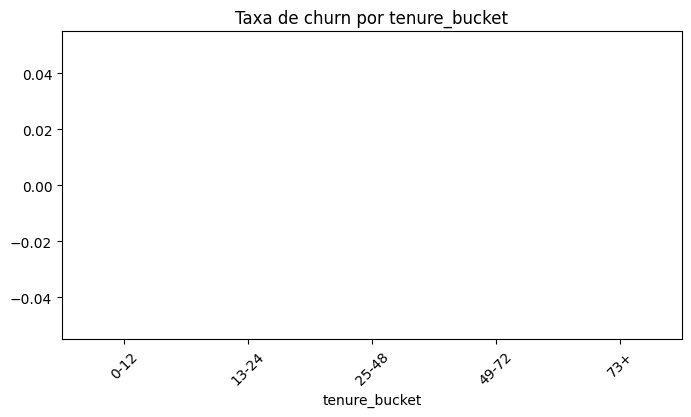

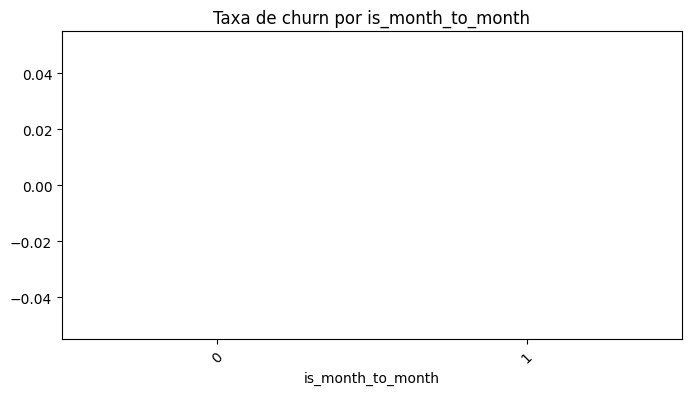

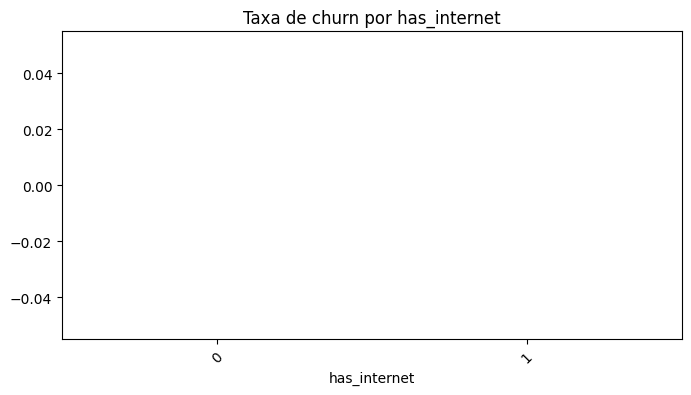

In [37]:
# Visualizar a taxa de churn nas novas features criadas
for col in ["tenure_bucket", "is_month_to_month", "has_internet"]:
    churn_rate = df_fe.groupby(col)["Churn"].mean().sort_values(ascending=False)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=churn_rate.index.astype(str), y=churn_rate.values)
    plt.title(f"Taxa de churn por {col}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
## Início da modelagem

In [39]:
# Importar bibliotecas para modelagem, pré-processamento e avaliação
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [41]:
# Recarregar o dataset original para evitar que a coluna Churn já convertida cause NaN
df = pd.read_csv("../data/dataset/telco_customer_churn.csv")

# Converter TotalCharges para numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Converter Churn para binário somente se ainda estiver como texto
if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Remover identificador do cliente
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

# Conferir se a variável alvo ficou sem valores ausentes
print(df["Churn"].isnull().sum())
df["Churn"].value_counts(dropna=False)

0


Churn
0    5174
1    1869
Name: count, dtype: int64

In [42]:
# Separar variáveis explicativas e variável alvo para modelagem baseline
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

X_train: (5634, 19)
X_test: (1409, 19)
Numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [43]:
# Criar o pipeline de pré-processamento para variáveis numéricas e categóricas
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])


In [44]:
# Criar uma função auxiliar para avaliar os modelos de classificação
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
    }

In [45]:
# Treinar um DummyClassifier como baseline ingênuo
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_metrics = evaluate_model(dummy, X_test, y_test)
dummy_metrics

{'accuracy': 0.7345635202271115,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5}

In [46]:
# Treinar uma Logistic Regression com pipeline de pré-processamento
logreg = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

logreg.fit(X_train, y_train)

logreg_metrics = evaluate_model(logreg, X_test, y_test)
logreg_metrics

{'accuracy': 0.7381121362668559,
 'precision': 0.504302925989673,
 'recall': 0.7834224598930482,
 'f1': 0.6136125654450262,
 'roc_auc': 0.8412978893797307}

In [47]:
# Feature engineering para melhorar o baseline
df_fe = df.copy()

df_fe["tenure_months"] = df_fe["tenure"]
df_fe["monthly_ratio"] = df_fe["TotalCharges"] / (df_fe["tenure"] + 1)

df_fe["Contract"] = df_fe["Contract"].replace({
    "Month-to-month": "Short",
    "One year": "Medium",
    "Two year": "Long"
})

df_fe["PaperlessBilling"] = df_fe["PaperlessBilling"].map({"Yes": 1, "No": 0})
df_fe["Partner"] = df_fe["Partner"].map({"Yes": 1, "No": 0})
df_fe["Dependents"] = df_fe["Dependents"].map({"Yes": 1, "No": 0})

X_fe = df_fe.drop(columns=["Churn"])
y_fe = df_fe["Churn"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

num_cols_fe = X_train_fe.select_dtypes(include="number").columns.tolist()
cat_cols_fe = X_train_fe.select_dtypes(exclude="number").columns.tolist()

num_pipe_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_fe = ColumnTransformer([
    ("num", num_pipe_fe, num_cols_fe),
    ("cat", cat_pipe_fe, cat_cols_fe),
])

logreg_fe = Pipeline([
    ("prep", preprocessor_fe),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

logreg_fe.fit(X_train_fe, y_train_fe)

logreg_fe_metrics = evaluate_model(logreg_fe, X_test_fe, y_test_fe)
logreg_fe_metrics

{'accuracy': 0.7430801987224982,
 'precision': 0.5104529616724739,
 'recall': 0.7834224598930482,
 'f1': 0.6181434599156118,
 'roc_auc': 0.8472913275982329}

In [ ]:
## Bloco da MLP

In [48]:
# Importar a classe da rede neural
from sklearn.neural_network import MLPClassifier

# Criar e treinar a MLP com pré-processamento
mlp = Pipeline([
    ("prep", preprocessor_fe),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42,
        early_stopping=True
    )),
])

# Ajustar o modelo aos dados de treino
mlp.fit(X_train_fe, y_train_fe)

# Avaliar o modelo no conjunto de teste
mlp_metrics = evaluate_model(mlp, X_test_fe, y_test_fe)
mlp_metrics

{'accuracy': 0.8034066713981547,
 'precision': 0.659016393442623,
 'recall': 0.5374331550802139,
 'f1': 0.5920471281296024,
 'roc_auc': 0.845937637241985}

In [ ]:
## Tabela final

In [49]:
# Organizar os resultados dos modelos em uma tabela comparativa
results = pd.DataFrame([
    {"model": "Dummy", "accuracy": dummy_metrics["accuracy"], "precision": dummy_metrics["precision"], "recall": dummy_metrics["recall"], "f1": dummy_metrics["f1"], "roc_auc": dummy_metrics["roc_auc"]},
    {"model": "LogReg", "accuracy": logreg_metrics["accuracy"], "precision": logreg_metrics["precision"], "recall": logreg_metrics["recall"], "f1": logreg_metrics["f1"], "roc_auc": logreg_metrics["roc_auc"]},
    {"model": "LogReg_FE", "accuracy": logreg_fe_metrics["accuracy"], "precision": logreg_fe_metrics["precision"], "recall": logreg_fe_metrics["recall"], "f1": logreg_fe_metrics["f1"], "roc_auc": logreg_fe_metrics["roc_auc"]},
    {"model": "MLP", "accuracy": mlp_metrics["accuracy"], "precision": mlp_metrics["precision"], "recall": mlp_metrics["recall"], "f1": mlp_metrics["f1"], "roc_auc": mlp_metrics["roc_auc"]},
])

# Exibir a tabela com duas casas decimais
results.round(3)

,model,accuracy,precision,recall,f1,roc_auc
0,Dummy,0.735,0.000,0.000,0.000,0.500
1,LogReg,0.738,0.504,0.783,0.614,0.841
2,LogReg_FE,0.743,0.510,0.783,0.618,0.847
3,MLP,0.803,0.659,0.537,0.592,0.846


In [50]:
# Identificar o modelo com maior F1
best_f1_model = results.loc[results["f1"].idxmax(), "model"]

# Identificar o modelo com maior ROC AUC
best_auc_model = results.loc[results["roc_auc"].idxmax(), "model"]

print("Melhor F1:", best_f1_model)
print("Melhor ROC AUC:", best_auc_model)

Melhor F1: LogReg_FE
Melhor ROC AUC: LogReg_FE


In [51]:
# Conclusão final da comparação de modelos
conclusao = """
A análise comparativa mostrou que o DummyClassifier serviu apenas como referência inicial, com desempenho limitado para o problema de churn. 
A Logistic Regression já apresentou melhora consistente, especialmente em recall e ROC AUC, mostrando capacidade real de discriminar clientes com risco de churn. 
Após o feature engineering, a Logistic Regression obteve o melhor equilíbrio entre as métricas avaliadas, com leve ganho em F1 e ROC AUC. 
A MLP apresentou maior accuracy, mas perdeu desempenho em recall e F1, o que a torna menos adequada para este caso.
Assim, o modelo escolhido foi a Logistic Regression com feature engineering, por oferecer o melhor compromisso entre detecção de churn e robustez geral.
"""

print(conclusao)



A análise comparativa mostrou que o DummyClassifier serviu apenas como referência inicial, com desempenho limitado para o problema de churn. 
A Logistic Regression já apresentou melhora consistente, especialmente em recall e ROC AUC, mostrando capacidade real de discriminar clientes com risco de churn. 
Após o feature engineering, a Logistic Regression obteve o melhor equilíbrio entre as métricas avaliadas, com leve ganho em F1 e ROC AUC. 
A MLP apresentou maior accuracy, mas perdeu desempenho em recall e F1, o que a torna menos adequada para este caso.
Assim, o modelo escolhido foi a Logistic Regression com feature engineering, por oferecer o melhor compromisso entre detecção de churn e robustez geral.

